# Visualize 2D PCA and regression results

This notebook only reads the compact artifacts produced by build_2d_shot_features.py and fit_2d_excitation_pca.py. It does not read the original HDF5 simulation files or refit PCA.

Expected artifact directory: ../results/2d-shot-features.

## Load saved artifacts

In [19]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

artifact_dir = Path("../results/r20-n200-a1e8-2d-shot-features-z0")
pca_path = artifact_dir / "2d-shot-pcas.npz"

manifest = json.loads((artifact_dir / "manifest.json").read_text())
metadata = np.load(artifact_dir / "shot_metadata.npz")
pca_artifact = np.load(pca_path)

run_groups = metadata["run_id"]
summary_feature_names = metadata["summary_names"].tolist()
summary_features = metadata["summary_features"]
pca_scores = pca_artifact["scores"]
components = pca_artifact["components"]
physical_pc_deltas = pca_artifact["physical_pc_deltas"]
explained_variance_ratio = pca_artifact["explained_variance_ratio"]
valid_pixels = pca_artifact["valid_pixels"]
representation = str(pca_artifact["representation"])
x_edges_2d = pca_artifact["x_edges"]
y_edges_2d = pca_artifact["y_edges"]

print(f"Loaded {manifest['n_shots']:,} shots from {manifest['n_runs']} runs.")
print(f"Summary features: {summary_feature_names}")
print(f"PCA representation: {representation}")
print(f"PCA scores: {pca_scores.shape}; valid pixels: {valid_pixels.sum():,}")


Loaded 4,000 shots from 20 runs.
Summary features: ['mean_x', 'mean_y', 'std_x', 'std_y', 'cov_xy', 'cov_x_state', 'cov_y_state', 'cov_x2_state', 'cov_y2_state', 'mean_x_exc', 'mean_y_exc']
PCA representation: fraction
PCA scores: (4000, 5); valid pixels: 3,464


## PCA components and explained variance

The first figure shows loadings in standardized-pixel space. The second translates each component into the physical profile change associated with a one-standard-deviation PCA score.

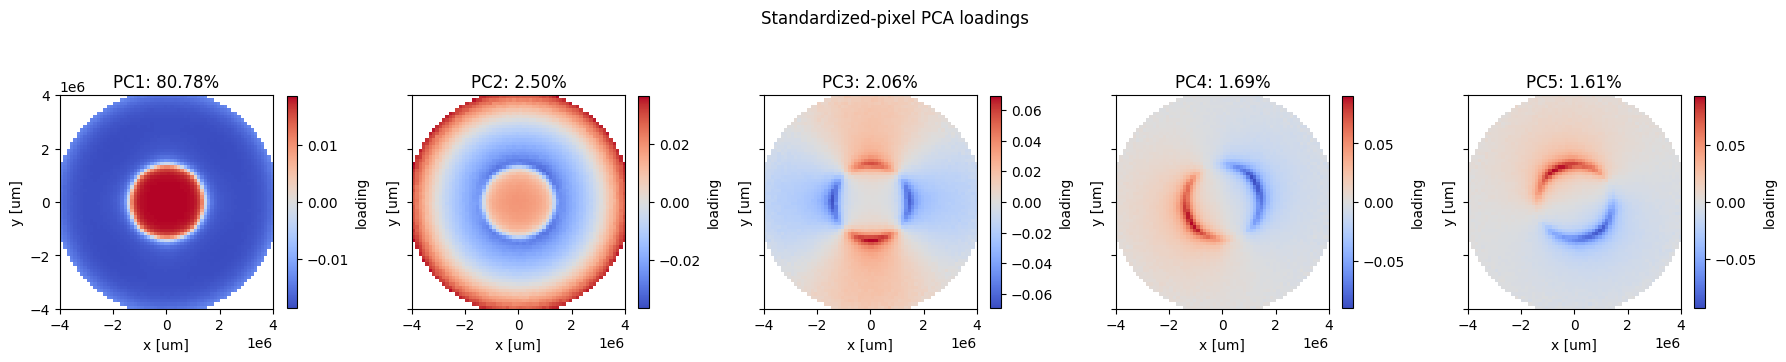

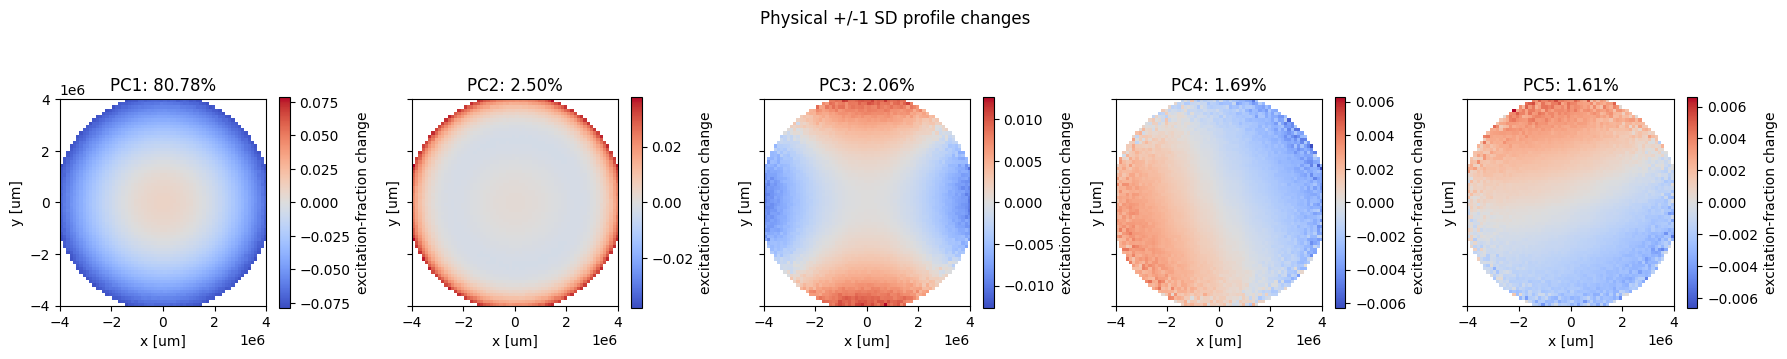

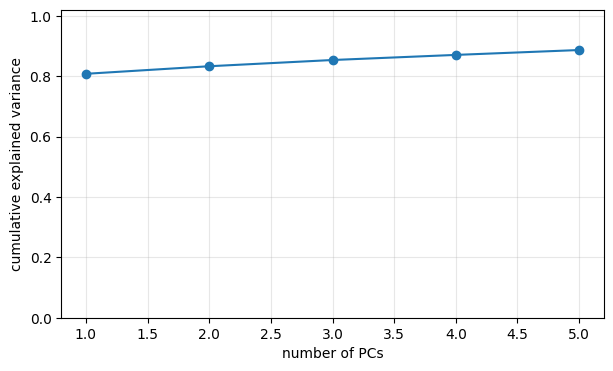

In [20]:
n_components_to_plot = min(10, len(components))
extent = [x_edges_2d[0] * 1e6, x_edges_2d[-1] * 1e6, y_edges_2d[0] * 1e6, y_edges_2d[-1] * 1e6]

def plot_component_maps(values, title, colorbar_label):
    ncols = 5
    nrows = int(np.ceil(len(values) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows), sharex=True, sharey=True)
    axs = np.atleast_1d(axs).flat
    for component_index, ax in enumerate(axs):
        if component_index >= len(values):
            ax.axis("off")
            continue
        image = np.full(valid_pixels.shape, np.nan)
        image[valid_pixels] = values[component_index]
        vmax = np.nanmax(np.abs(image))
        im = ax.imshow(image.T, origin="lower", extent=extent, cmap="coolwarm", vmin=-vmax, vmax=vmax)
        ax.set_title(f"PC{component_index + 1}: {explained_variance_ratio[component_index]:.2%}")
        ax.set_xlabel("x [um]")
        ax.set_ylabel("y [um]")
        fig.colorbar(im, ax=ax, shrink=0.75, label=colorbar_label)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()

plot_component_maps(components[:n_components_to_plot], "Standardized-pixel PCA loadings", "loading")
plot_component_maps(physical_pc_deltas[:n_components_to_plot], "Physical +/-1 SD profile changes", "excitation-fraction change")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), marker="o")
plt.xlabel("number of PCs")
plt.ylabel("cumulative explained variance")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)


## Gradient and curvature template overlaps

,x gradient,y gradient,x curvature,xy curvature,y curvature,radial curvature
PC1,0.000,0.000,0.616,0.000,0.619,1.000
PC2,0.023,0.011,0.019,0.002,0.034,0.012
PC3,0.027,0.086,0.783,0.000,0.780,0.007
PC4,0.916,0.393,0.007,0.000,0.008,0.001
PC5,0.394,0.913,0.074,0.000,0.073,0.001


,x gradient,y gradient,x curvature,xy curvature,y curvature,radial curvature
PC1,0.000,0.000,0.379,0.0,0.383,0.999
PC2,0.001,0.000,0.380,0.0,0.384,1.000
PC3,0.001,0.008,0.993,0.0,0.993,1.000
PC4,0.840,0.162,0.993,0.0,0.993,1.000
PC5,0.996,0.996,0.998,0.0,0.998,1.000


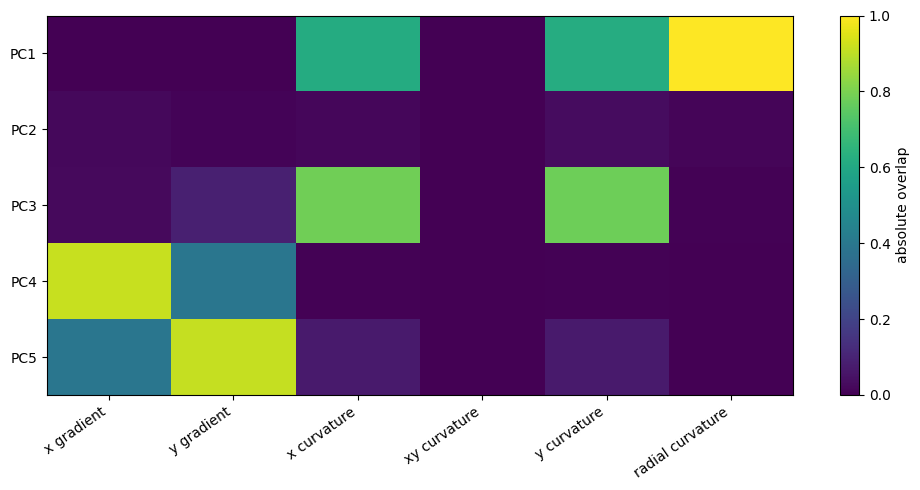

In [21]:
x_centers = 0.5 * (x_edges_2d[:-1] + x_edges_2d[1:])
y_centers = 0.5 * (y_edges_2d[:-1] + y_edges_2d[1:])
x_grid, y_grid = np.meshgrid(x_centers, y_centers, indexing="ij")
x_valid = x_grid[valid_pixels]
y_valid = y_grid[valid_pixels]

mean_count_weights = pca_artifact["mean_valid_counts"]
mean_count_weights = mean_count_weights / mean_count_weights.sum()

def centered(values):
    return values - np.sum(mean_count_weights * values)

templates = {
    "x gradient": centered(x_valid),
    "y gradient": centered(y_valid),
    "x curvature": centered(x_valid**2),
    "xy curvature": centered(x_valid * y_valid),
    "y curvature": centered(y_valid**2),
    "radial curvature": centered(x_valid**2 + y_valid**2),
}
scaler_scale = pca_artifact["scaler_scale"]
standardized_templates = {name: values / scaler_scale for name, values in templates.items()}
standardized_templates = {name: values / np.linalg.norm(values) for name, values in standardized_templates.items()}
overlaps = pd.DataFrame(
    {name: np.abs(components @ template) for name, template in standardized_templates.items()},
    index=[f"PC{i + 1}" for i in range(len(components))],
)
display(overlaps.round(3))
display((overlaps**2).cumsum().round(3))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(overlaps.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(overlaps.columns)), overlaps.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(overlaps.index)), overlaps.index)
fig.colorbar(im, ax=ax, label="absolute overlap")
fig.tight_layout()


## Quadratic regression on all shots

These fits answer whether the saved summary features and PCA scores contain enough information to reconstruct each initial condition. Since predictions are made on the fitted data, this is a relationship diagnostic rather than an estimate of generalization performance.

,R2,RMSE
target,,
mu_x0,0.092042,9.564216e-06
mu_y0,0.090516,9.386203e-06
sigma_x0,0.050416,9.799280e-06
sigma_y0,0.057188,9.726004e-06
mu_vx0,0.939012,2.487760e-06
mu_vy0,0.940595,2.441657e-06
sigma_vx0,0.995483,6.767218e-07
sigma_vy0,0.995581,6.656019e-07


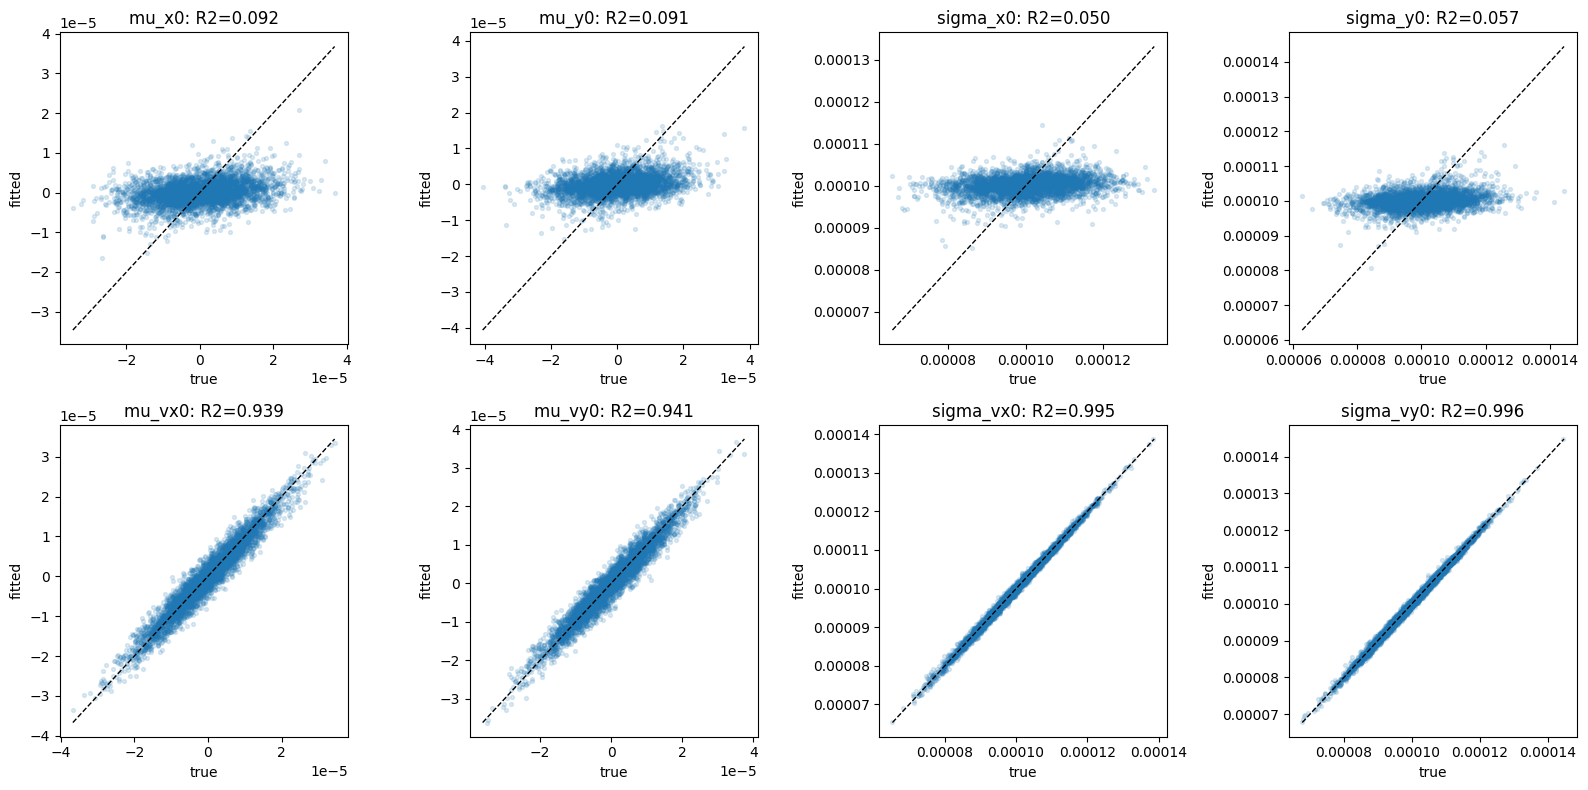

In [22]:
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

n_predictive_pcs = min(5, pca_scores.shape[1])
feature_names = summary_feature_names + [f"PC{i + 1}_score" for i in range(n_predictive_pcs)]
X = np.column_stack([summary_features, pca_scores[:, :n_predictive_pcs]])
targets = {
    "mu_x0": metadata["mu_x0"], "mu_y0": metadata["mu_y0"],
    "sigma_x0": metadata["sigma_x"], "sigma_y0": metadata["sigma_y"],
    "mu_vx0": metadata["mu_vx0"], "mu_vy0": metadata["mu_vy0"],
    "sigma_vx0": metadata["sigma_vx"], "sigma_vy0": metadata["sigma_vy"],
}
quadratic_model = Pipeline([
    ("input_scaler", StandardScaler()),
    ("quadratic_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("quadratic_scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1e-2)),
])

all_data_rows = []
all_data_predictions = {}
all_data_models = {}
for target_name, y in targets.items():
    model = clone(quadratic_model).fit(X, y)
    prediction = model.predict(X)
    all_data_predictions[target_name] = prediction
    all_data_models[target_name] = model
    all_data_rows.append({"target": target_name, "R2": r2_score(y, prediction), "RMSE": np.sqrt(np.mean((y - prediction)**2))})
all_data_results = pd.DataFrame(all_data_rows).set_index("target")
display(all_data_results)

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for ax, (target_name, y) in zip(axs.flat, targets.items()):
    prediction = all_data_predictions[target_name]
    lo, hi = min(y.min(), prediction.min()), max(y.max(), prediction.max())
    ax.scatter(y, prediction, alpha=0.15, s=8)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_title(f"{target_name}: R2={r2_score(y, prediction):.3f}")
    ax.set_xlabel("true")
    ax.set_ylabel("fitted")
fig.tight_layout()


## Strongest regression coefficients

Coefficients are ranked within each target after standardizing both the input features and generated quadratic terms. Their magnitudes are therefore comparable within a target; their signs indicate the fitted direction of the relationship.

term  standardized_coefficient  \
target    rank                                                       
mu_x0     1         mean_x_exc PC1_score                  0.000071   
          2             mean_x PC1_score                 -0.000063   
          3             mean_x PC4_score                 -0.000055   
          4         mean_x_exc PC4_score                  0.000054   
          5      cov_x2_state mean_x_exc                  0.000043   
          6          mean_x cov_x2_state                 -0.000041   
          7        cov_x_state PC4_score                 -0.000037   
          8             mean_x PC5_score                  0.000031   
          9         mean_x_exc PC5_score                 -0.000031   
          10      cov_x_state mean_x_exc                  0.000030   
mu_y0     1        cov_y_state PC5_score                  0.000051   
          2       cov_y_state mean_y_exc                 -0.000046   
          3           mean_y cov_y_state                  0.000043   
          4          mean_x cov_x2_state                 -0.000039   
          5          mean_y cov_x2_state                  0.000037   
          6         mean_y_exc PC5_score                  0.000037   
          7      cov_x2_state mean_x_exc                  0.000036   
          8      cov_x2_state mean_y_exc                 -0.000034   
          9             mean_y PC5_score                 -0.000032   
          10      cov_x2_state PC4_score                 -0.000032   
sigma_x0  1             mean_x PC1_score                 -0.000056   
          2       cov_y2_state PC1_score                  0.000054   
          3       cov_x2_state PC1_score                 -0.000046   
          4      cov_x2_state mean_y_exc                 -0.000045   
          5          mean_y cov_x2_state                  0.000044   
          6             mean_y PC1_score                  0.000044   
          7         mean_y_exc PC1_score                 -0.000042   
          8         mean_x_exc PC1_score                  0.000042   
          9          mean_x cov_y2_state                 -0.000036   
          10       cov_x_state PC4_score                 -0.000035   
sigma_y0  1       cov_x2_state PC1_score                  0.000058   
          2          mean_y cov_y2_state                 -0.000048   
          3      cov_y2_state mean_y_exc                  0.000046   
          4     cov_y_state cov_y2_state                  0.000040   
          5         mean_y_exc PC4_score                 -0.000037   
          6                 cov_x2_state                 -0.000037   
          7       cov_x2_state PC5_score                  0.000035   
          8             mean_y PC4_score                  0.000033   
          9       cov_y2_state PC5_score                 -0.000033   
          10        mean_x_exc PC1_score                 -0.000032   
mu_vx0    1         mean_x_exc PC1_score                 -0.000018   
          2             mean_x PC1_score                  0.000016   
          3             mean_x PC4_score                  0.000014   
          4         mean_x_exc PC4_score                 -0.000014   
          5      cov_x2_state mean_x_exc                 -0.000011   
          6          mean_x cov_x2_state                  0.000010   
          7        cov_x_state PC4_score                  0.000010   
          8             mean_x PC5_score                 -0.000008   
          9         mean_x_exc PC5_score                  0.000008   
          10      cov_x_state mean_x_exc                 -0.000008   
mu_vy0    1                       mean_y                  0.000015   
          2        cov_y_state PC5_score                 -0.000013   
          3       cov_y_state mean_y_exc                  0.000012   
          4           mean_y cov_y_state                 -0.000011   
          5          mean_x cov_x2_state                  0.000010   
          6          mean_y cov_x2_state      

                                    term  standardized_coefficient  absolute_coefficient
target    rank                                                                          
mu_x0     1         mean_x_exc PC1_score                  0.000071              0.000071
          2             mean_x PC1_score                 -0.000063              0.000063
          3             mean_x PC4_score                 -0.000055              0.000055
          4         mean_x_exc PC4_score                  0.000054              0.000054
          5      cov_x2_state mean_x_exc                  0.000043              0.000043
          6          mean_x cov_x2_state                 -0.000041              0.000041
          7        cov_x_state PC4_score                 -0.000037              0.000037
          8             mean_x PC5_score                  0.000031              0.000031
          9         mean_x_exc PC5_score                 -0.000031              0.000031
          10      cov

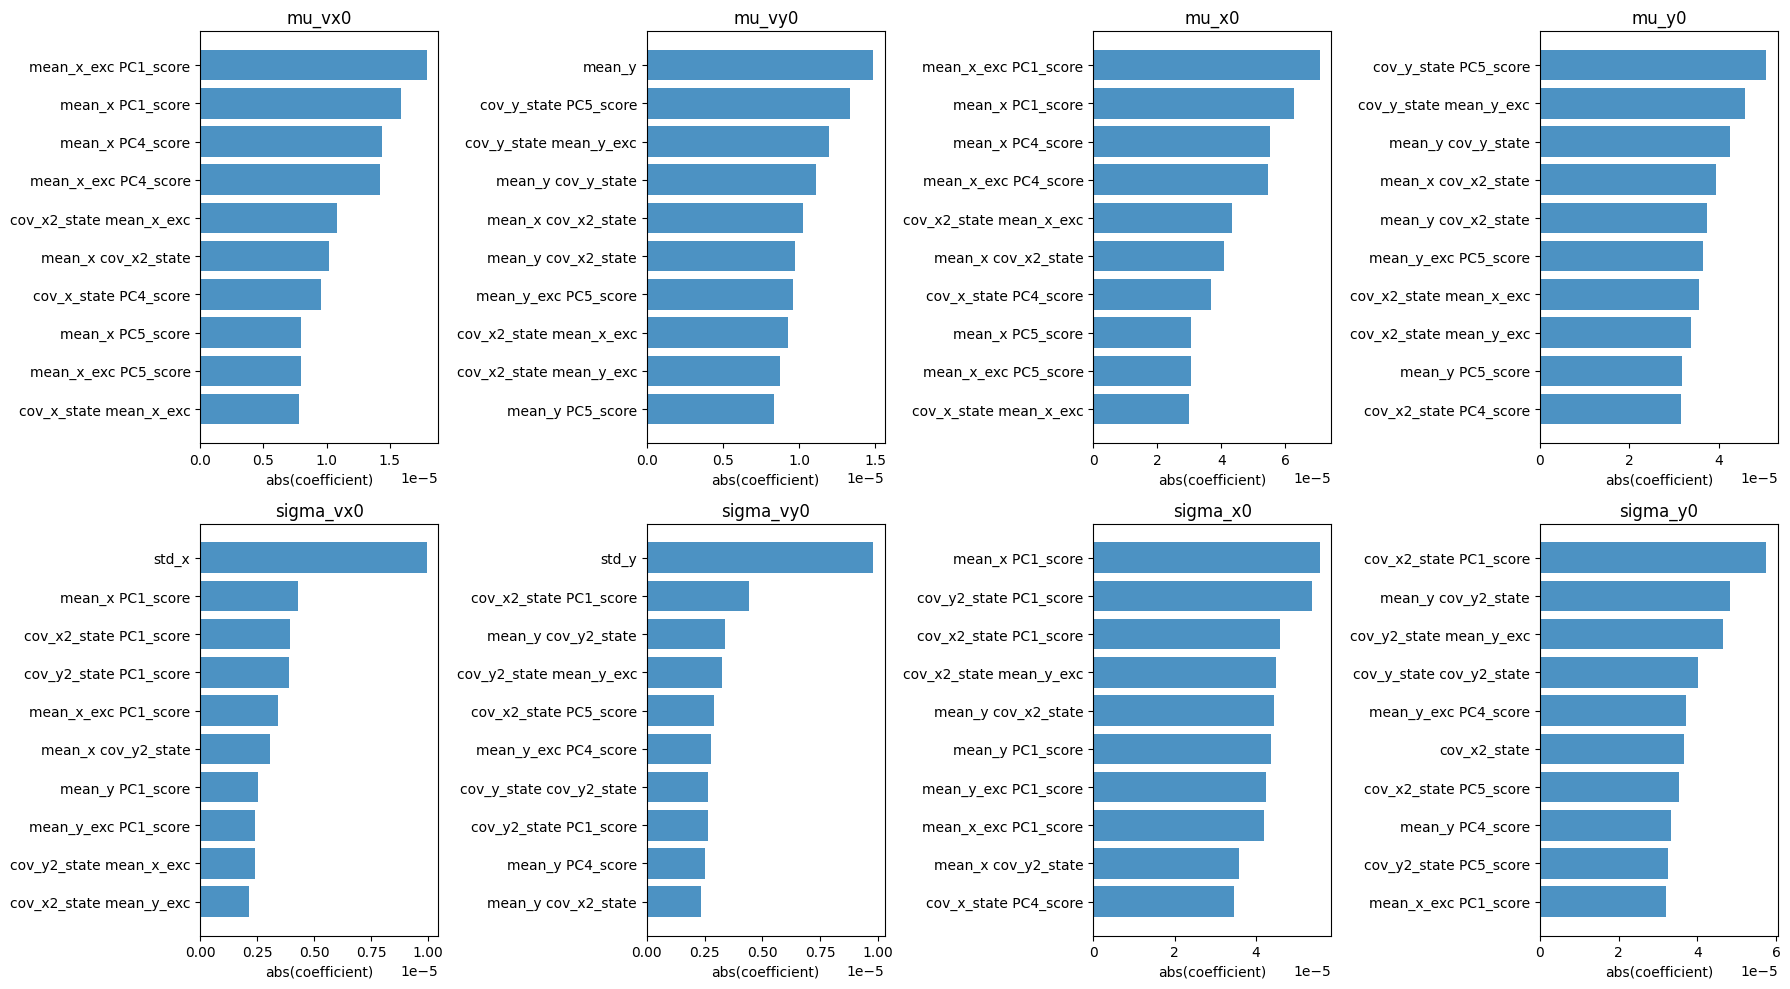

In [23]:
top_n_coefficients = 10
quadratic_feature_names = next(iter(all_data_models.values())).named_steps["quadratic_features"].get_feature_names_out(feature_names)

coefficient_rows = []
for target_name, fitted_model in all_data_models.items():
    coefficients = fitted_model.named_steps["ridge"].coef_
    strongest_indices = np.argsort(np.abs(coefficients))[-top_n_coefficients:][::-1]
    for rank, index in enumerate(strongest_indices, start=1):
        coefficient_rows.append({
            "target": target_name,
            "rank": rank,
            "term": quadratic_feature_names[index],
            "standardized_coefficient": coefficients[index],
            "absolute_coefficient": abs(coefficients[index]),
        })

top_coefficient_table = pd.DataFrame(coefficient_rows).set_index(["target", "rank"])

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(top_coefficient_table)

print(top_coefficient_table.to_string())

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharey=False)
for ax, target_name in zip(axs.flat, sorted(all_data_models.keys())):
    target_table = top_coefficient_table.loc[target_name].sort_index(level="rank")
    ax.barh(target_table["term"], target_table["absolute_coefficient"], color="C0", alpha=0.8)
    ax.set_title(target_name)
    ax.set_xlabel("abs(coefficient)")
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Held-out-run regression check

This optional check holds out complete simulation runs, giving a stricter indication of whether the relationship transfers beyond the runs used to fit the model.

In [24]:
from sklearn.model_selection import GroupShuffleSplit

unique_runs = np.unique(run_groups)
if len(unique_runs) < 2:
    print("Grouped holdout skipped: at least two complete runs are required.")
else:
    train_index, test_index = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, groups=run_groups))
    holdout_rows = []
    for target_name, y in targets.items():
        model = clone(quadratic_model).fit(X[train_index], y[train_index])
        prediction = model.predict(X[test_index])
        holdout_rows.append({
            "target": target_name,
            "held_out_run_R2": r2_score(y[test_index], prediction),
            "held_out_run_RMSE": np.sqrt(np.mean((y[test_index] - prediction)**2)),
        })
    display(pd.DataFrame(holdout_rows).set_index("target"))
    print(f"Held out {len(np.unique(run_groups[test_index]))} complete runs ({len(test_index):,} shots).")


,held_out_run_R2,held_out_run_RMSE
target,,
mu_x0,0.007371,9.864329e-06
mu_y0,-0.006861,9.914963e-06
sigma_x0,-0.031817,1.046769e-05
sigma_y0,-0.012588,1.012887e-05
mu_vx0,0.936845,2.565774e-06
mu_vy0,0.931307,2.577915e-06
sigma_vx0,0.994961,7.223622e-07
sigma_vy0,0.995428,6.780899e-07


Held out 4 complete runs (800 shots).
